In [30]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)


In [31]:
file_path = 'household_power_consumption.csv'   
df = pd.read_csv(file_path, 
                 sep=';',parse_dates={'datetime': ['Date', 'Time']},  infer_datetime_format=True,  na_values=['?'], low_memory=False)

print("Shape (Rows, Columns):", df.shape)
display(df.head())


Shape (Rows, Columns): (2075259, 8)


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [32]:
power_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
              'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for col in power_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [33]:
df = df.dropna()

In [34]:
df.set_index('datetime', inplace=True)

In [35]:
daily_df = df['Global_active_power'].resample('D').sum().to_frame(name='Energy_kWh')


print("Daily Shape:", daily_df.shape)
print("First 5 days of daily energy:")
display(daily_df.head())


daily_df['Year'] = daily_df.index.year
daily_df['Month'] = daily_df.index.month
daily_df['DayOfWeek'] = daily_df.index.dayofweek
daily_df['IsWeekend'] = daily_df['DayOfWeek'].isin([5, 6]).astype(int)

Daily Shape: (1442, 1)
First 5 days of daily energy:


,Energy_kWh
datetime,
2006-12-16,1209.176
2006-12-17,3390.460
2006-12-18,2203.826
2006-12-19,1666.194
2006-12-20,2225.748


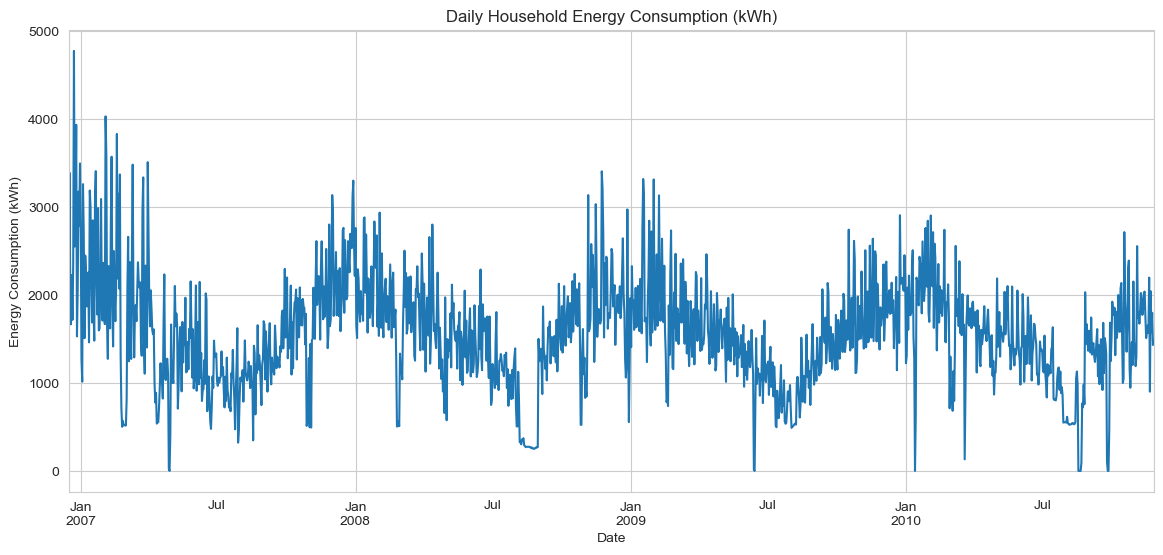

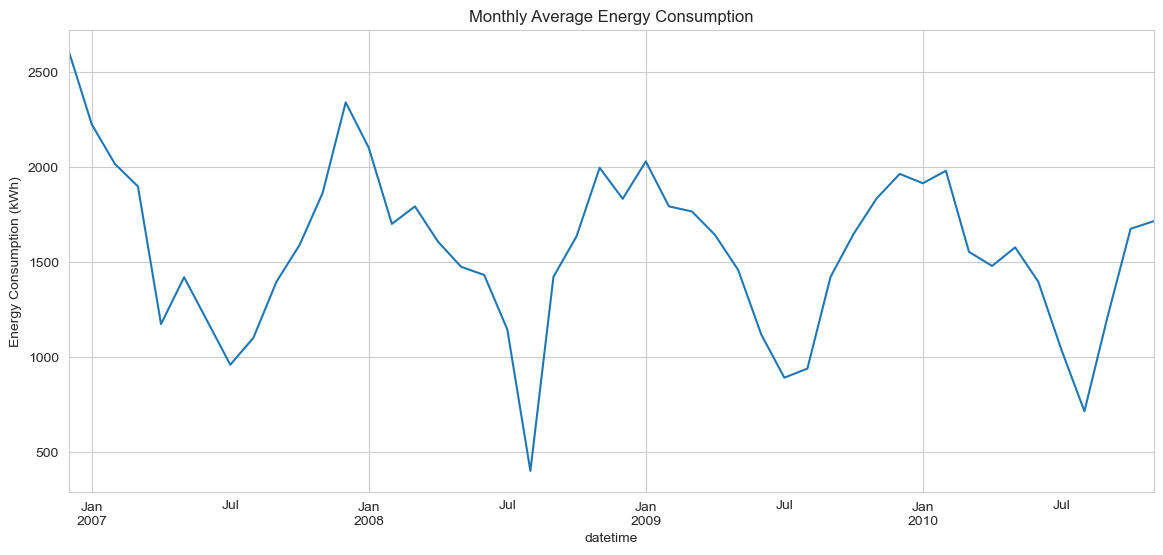

In [36]:
#daily energy onsumption
plt.figure()
daily_df['Energy_kWh'].plot(title='Daily Household Energy Consumption (kWh)')
plt.ylabel('Energy Consumption (kWh)')
plt.xlabel('Date')
plt.show()

#monthly average
monthly_avg = daily_df['Energy_kWh'].resample('M').mean()
plt.figure()
monthly_avg.plot(title='Monthly Average Energy Consumption')
plt.ylabel('Energy Consumption (kWh)')
plt.show()